# Loan Approval Prediction Model

## Objective

Analyze the "Loan-Approval-Prediction-Dataset" dataset to predict loan approval. This involves data preprocessing, exploratory data analysis (EDA), handling class imbalance with SMOTE, training multiple classification models, and comparing their performance.

## Dataset Overview

The dataset contains features such as number of dependents, education, self-employment status, income, loan amount, loan term, CIBIL score, and various asset values. The target variable is loan_status (Approved/Rejected).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Data Loading and Initial Exploration

Load the dataset and perform initial checks.

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nData Types:')
print(df.dtypes)
print('\nSummary Statistics:')
display(df.describe())

Dataset Shape: (4269, 13)

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Data Types:
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Summary Statistics:


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Missing Values Check

Check for any missing values in the dataset.

In [3]:
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal Missing Values:', df.isnull().sum().sum())

Missing Values per Column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Total Missing Values: 0


## Exploratory Data Analysis (EDA)

Visualize the data to understand distributions and relationships.

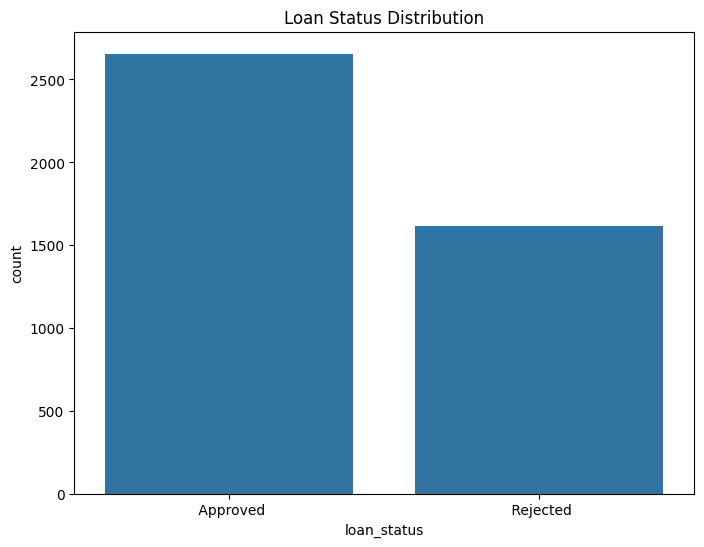

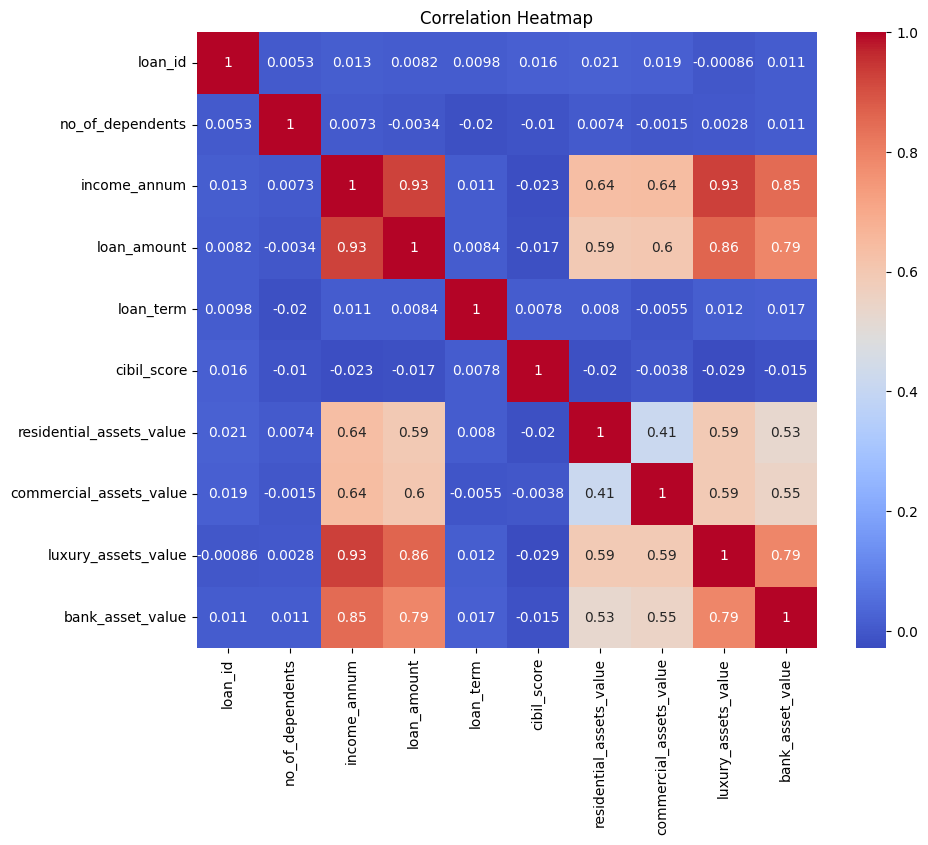

In [4]:
plt.figure(figsize=(8,6))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<Figure size 1200x1000 with 0 Axes>

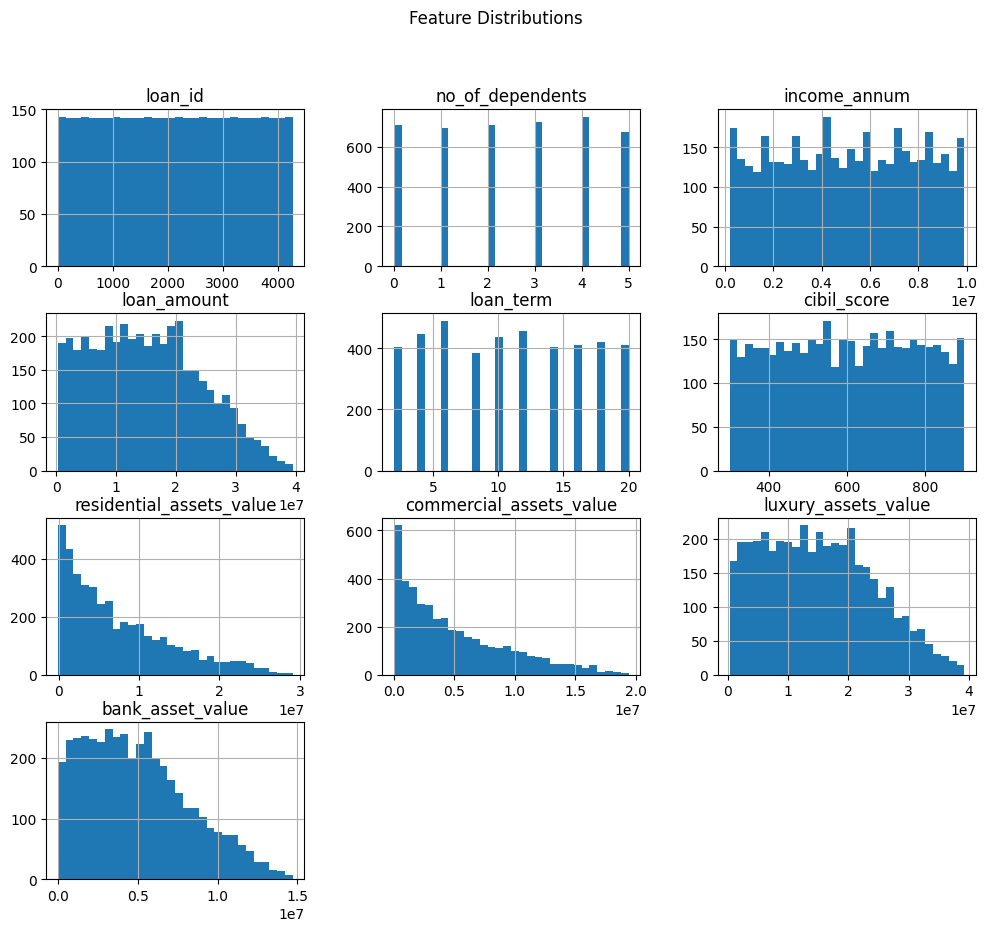

In [5]:
plt.figure(figsize=(12,10))
df.select_dtypes(include=[np.number]).hist(bins=30, figsize=(12,10))
plt.suptitle('Feature Distributions')
plt.show()

## Data Preprocessing

Encode categorical features and prepare data for modeling.

In [6]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])  # 0: Rejected, 1: Approved

print('Encoded Data:')
display(df.head())

Encoded Data:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Train-Test Split

Split the data into training and testing sets.

In [7]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Target distribution in train:', y_train.value_counts(normalize=True))
print('Target distribution in test:', y_test.value_counts(normalize=True))

Train shape: (3415, 12)
Test shape: (854, 12)
Target distribution in train: loan_status
0    0.622255
1    0.377745
Name: proportion, dtype: float64
Target distribution in test: loan_status
0    0.62178
1    0.37822
Name: proportion, dtype: float64


## Model Training and Evaluation

### Random Forest Classifier

Train a Random Forest model on the original data.

Random Forest Results:
Accuracy: 0.9801
Precision: 0.9873
Recall: 0.9598
F1-Score: 0.9733

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       531
           1       0.99      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



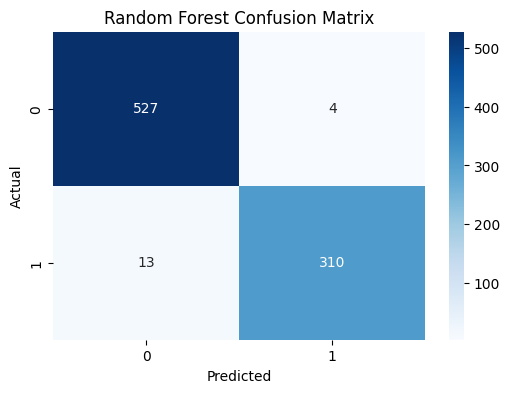

In [8]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print('Random Forest Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Handling Class Imbalance with SMOTE

Apply SMOTE to balance the training data.

In [9]:
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_resampled.value_counts().to_dict())

Before SMOTE: {0: 2125, 1: 1290}
After SMOTE: {1: 2125, 0: 2125}


### Logistic Regression with SMOTE

Logistic Regression with SMOTE Results:


Accuracy: 0.8126
Precision: 0.7621
Recall: 0.7337
F1-Score: 0.7476

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       531
           1       0.76      0.73      0.75       323

    accuracy                           0.81       854
   macro avg       0.80      0.80      0.80       854
weighted avg       0.81      0.81      0.81       854



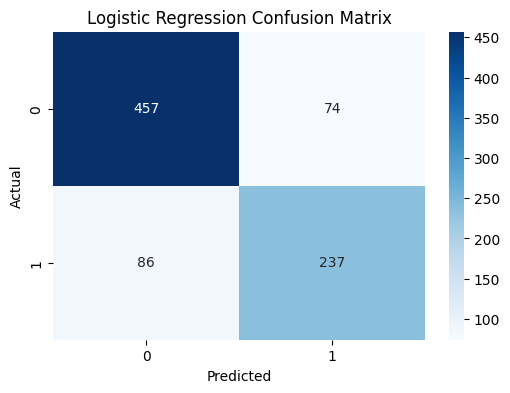

In [10]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_resampled, y_resampled)
y_pred_lr = lr_model.predict(X_test)
print('Logistic Regression with SMOTE Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Decision Tree with SMOTE

Decision Tree with SMOTE Results:
Accuracy: 0.9801
Precision: 0.9752
Recall: 0.9721
F1-Score: 0.9736

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       531
           1       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



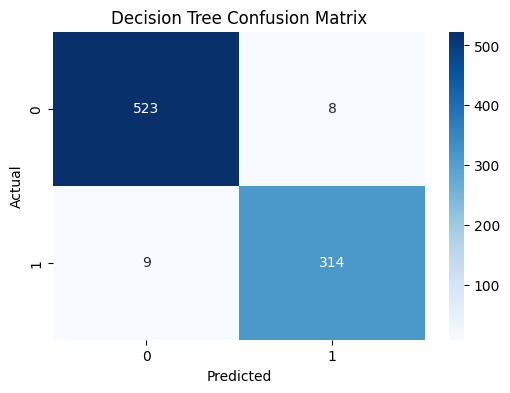

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_resampled, y_resampled)
y_pred_dt = dt_model.predict(X_test)
print('Decision Tree with SMOTE Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_dt):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model Comparison

Compare the performance of all models.

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.980094,0.987261,0.959752,0.973312
1,Logistic Regression (SMOTE),0.812646,0.762058,0.733746,0.747634
2,Decision Tree (SMOTE),0.980094,0.975155,0.972136,0.973643


<Figure size 1000x600 with 0 Axes>

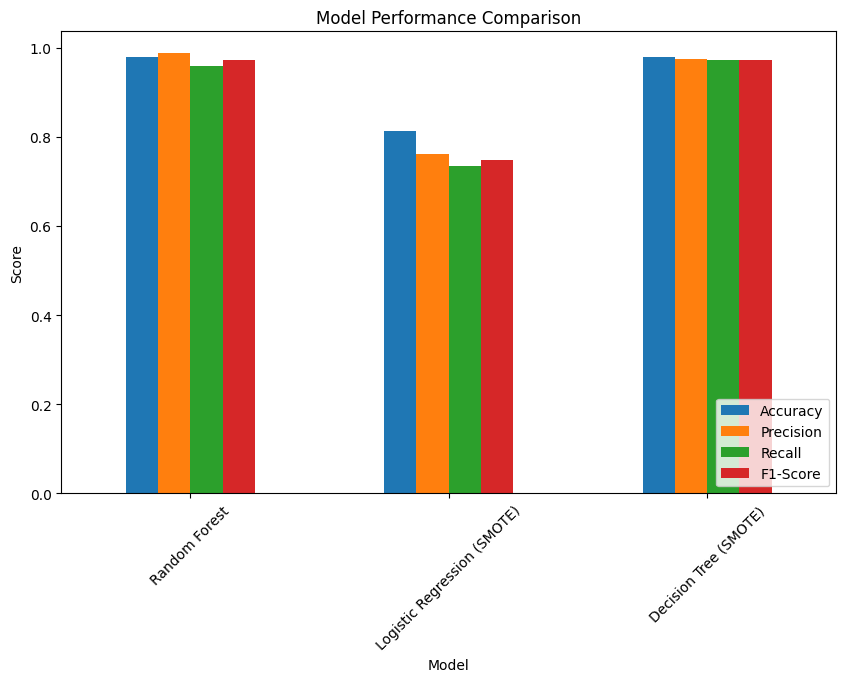

In [12]:
models = ['Random Forest', 'Logistic Regression (SMOTE)', 'Decision Tree (SMOTE)']
accuracies = [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)]
precisions = [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt)]
recalls = [recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt)]
f1_scores = [f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt)]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})
print('Model Comparison:')
display(comparison_df)

plt.figure(figsize=(10,6))
comparison_df.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

## Conclusion

- The Random Forest model performed best on the original data with high accuracy and F1-score.
- After applying SMOTE, Logistic Regression and Decision Tree showed improved recall but slightly lower precision.
- For loan approval prediction, consider the trade-off between precision and recall based on business requirements.
- Further improvements could include hyperparameter tuning, feature engineering, or trying other algorithms like XGBoost.